In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("outputs", exist_ok=True)
print("Project directory ready.")

Project directory ready.


In [2]:
%%writefile config.py
import numpy as np

# Core mathematical values
Y0 = 0.0
T0 = 0.0
ALPHA_CRIT = float(np.e)

# Representative test cases
ALPHA_BELOW = 2.5
ALPHA_AT = ALPHA_CRIT
ALPHA_ABOVE = 3.2
ALPHA_VALUES = [ALPHA_BELOW, ALPHA_AT, ALPHA_ABOVE]

# Fixed-step solver settings
DT_FIXED = 1e-3
TMAX_FIXED = 5.0

# Adaptive solver settings
DT_INIT = 1e-2
DT_MIN = 1e-8
DT_MAX = 1e-1
STEP_GROWTH = 2.0
STEP_SHRINK = 0.5

# Step acceptance thresholds based on |y_{n+1} - y_n|
DELTA_Y_MAX = 5e-2
DELTA_Y_MIN = 1e-4

# Safety / termination
Y_EXPLOSION = 20.0
MAX_STEPS = 200000

# Plotting settings
Y_PLOT_MIN = 0.0
Y_PLOT_MAX = 5.0
Y_PLOT_NUM = 1000
FIG_DPI = 150

Writing config.py


In [3]:
%%writefile model.py
import numpy as np

def rhs(y: float, alpha: float) -> float:
    """
    Right-hand side of the ODE:
        y' = exp(y) - alpha*y
    """
    return float(np.exp(y) - alpha * y)

def rhs_vectorized(y, alpha):
    """
    Vectorized version for numpy arrays.
    """
    return np.exp(y) - alpha * y

Writing model.py


In [4]:
%%writefile utils.py
import os
import json
import numpy as np

def safe_exp(y, clip=700.0):
    """
    Exponential with clipping to reduce overflow risk.
    """
    return np.exp(np.clip(y, None, clip))

def format_alpha(alpha: float) -> str:
    """
    Clean string for alpha in titles / filenames.
    """
    return f"{alpha:.6f}".replace(".", "p")

def make_output_dir(path="outputs"):
    os.makedirs(path, exist_ok=True)

def save_json(data: dict, filepath: str):
    with open(filepath, "w") as f:
        json.dump(data, f, indent=2)

def to_numpy(x):
    return np.asarray(x, dtype=float)

Writing utils.py


In [5]:
%%writefile equilibrium.py
import numpy as np
from model import rhs_vectorized

def critical_alpha() -> float:
    """
    Exact critical parameter from tangency:
        alpha_crit = e
    """
    return float(np.e)

def critical_equilibrium() -> float:
    """
    At tangency, y* = 1.
    """
    return 1.0

def equilibrium_residual(y: float, alpha: float) -> float:
    """
    Residual for equilibrium equation:
        exp(y) - alpha*y = 0
    """
    return float(np.exp(y) - alpha * y)

def exp_curve(y):
    return np.exp(y)

def line_curve(y, alpha):
    return alpha * y

def find_equilibria_on_grid(alpha, y_min=0.0, y_max=10.0, n=20000):
    """
    Approximate equilibrium points by detecting sign changes in
        exp(y) - alpha*y
    over a dense grid, then linearly interpolating.

    Returns
    -------
    roots : list of floats
    """
    y = np.linspace(y_min, y_max, n)
    f = rhs_vectorized(y, alpha)

    roots = []
    for i in range(len(y) - 1):
        f1, f2 = f[i], f[i + 1]
        if f1 == 0:
            roots.append(float(y[i]))
        elif f1 * f2 < 0:
            # Linear interpolation
            yi, yj = y[i], y[i + 1]
            root = yi - f1 * (yj - yi) / (f2 - f1)
            roots.append(float(root))

    # Remove near-duplicates
    dedup = []
    for r in roots:
        if not dedup or abs(r - dedup[-1]) > 1e-4:
            dedup.append(r)

    return dedup

Writing equilibrium.py


In [6]:
%%writefile fixed_solver.py
import numpy as np
from model import rhs

def improved_euler_fixed(alpha, y0, t0, tmax, dt, y_explosion=20.0, max_steps=200000):
    """
    Fixed-step improved Euler (Heun / explicit trapezoid) solver.

    Scheme:
        y_tilde = y_n + dt*F(y_n)
        y_{n+1} = y_n + 0.5*dt*(F(y_n) + F(y_tilde))
    """
    t_values = [float(t0)]
    y_values = [float(y0)]

    t = float(t0)
    y = float(y0)
    step_count = 0
    blowup_detected = False
    termination_reason = "Reached tmax"

    while t < tmax and step_count < max_steps:
        if y >= y_explosion:
            blowup_detected = True
            termination_reason = "Explosion threshold reached"
            break

        dt_step = min(dt, tmax - t)

        f_n = rhs(y, alpha)
        y_tilde = y + dt_step * f_n
        f_tilde = rhs(y_tilde, alpha)
        y_next = y + 0.5 * dt_step * (f_n + f_tilde)
        t_next = t + dt_step

        if not np.isfinite(y_next):
            blowup_detected = True
            termination_reason = "Non-finite value encountered"
            break

        t_values.append(float(t_next))
        y_values.append(float(y_next))

        t = t_next
        y = y_next
        step_count += 1

    if step_count >= max_steps:
        termination_reason = "Maximum number of steps reached"

    return {
        "t": np.array(t_values, dtype=float),
        "y": np.array(y_values, dtype=float),
        "alpha": float(alpha),
        "dt": float(dt),
        "method": "improved_euler_fixed",
        "blowup_detected": bool(blowup_detected),
        "termination_reason": termination_reason,
        "num_steps": int(step_count),
    }

Writing fixed_solver.py


In [7]:
%%writefile adaptive_solver.py
import numpy as np
from model import rhs

def improved_euler_adaptive(
    alpha,
    y0,
    t0,
    tmax,
    dt_init,
    dt_min,
    dt_max,
    delta_y_max,
    delta_y_min,
    step_shrink=0.5,
    step_grow=2.0,
    y_explosion=20.0,
    max_steps=200000,
):
    """
    Primitive adaptive improved Euler solver.

    Adaptivity is based on:
        delta_y = |y_{n+1} - y_n|

    Policy:
    - if delta_y > delta_y_max: reject step and shrink dt
    - if delta_y < delta_y_min: accept step and consider growing dt
    - else: accept step and keep dt
    """
    t_values = [float(t0)]
    y_values = [float(y0)]
    dt_history = []

    t = float(t0)
    y = float(y0)
    dt = float(dt_init)

    accepted_steps = 0
    rejected_steps = 0
    total_attempts = 0

    blowup_detected = False
    termination_reason = "Reached tmax"

    while t < tmax and total_attempts < max_steps:
        if y >= y_explosion:
            blowup_detected = True
            termination_reason = "Explosion threshold reached"
            break

        dt = min(dt, dt_max)
        dt = max(dt, dt_min)
        dt_step = min(dt, tmax - t)

        f_n = rhs(y, alpha)
        y_tilde = y + dt_step * f_n
        f_tilde = rhs(y_tilde, alpha)
        y_trial = y + 0.5 * dt_step * (f_n + f_tilde)

        if not np.isfinite(y_trial):
            dt *= step_shrink
            rejected_steps += 1
            total_attempts += 1
            if dt < dt_min:
                blowup_detected = True
                termination_reason = "Step size fell below dt_min after non-finite trial"
                break
            continue

        delta_y = abs(y_trial - y)

        # Reject overly large jump
        if delta_y > delta_y_max:
            dt *= step_shrink
            rejected_steps += 1
            total_attempts += 1
            if dt < dt_min:
                blowup_detected = True
                termination_reason = "Step size fell below dt_min during rejection"
                break
            continue

        # Accept the step
        t = t + dt_step
        y = y_trial
        t_values.append(float(t))
        y_values.append(float(y))
        dt_history.append(float(dt_step))
        accepted_steps += 1
        total_attempts += 1

        # Grow timestep if solution change is very small
        if delta_y < delta_y_min:
            dt = min(dt_max, dt * step_grow)

    if total_attempts >= max_steps:
        termination_reason = "Maximum number of attempts reached"

    return {
        "t": np.array(t_values, dtype=float),
        "y": np.array(y_values, dtype=float),
        "dt_history": np.array(dt_history, dtype=float),
        "accepted_steps": int(accepted_steps),
        "rejected_steps": int(rejected_steps),
        "alpha": float(alpha),
        "method": "improved_euler_adaptive",
        "blowup_detected": bool(blowup_detected),
        "termination_reason": termination_reason,
        "num_steps": int(accepted_steps),
    }

Writing adaptive_solver.py


In [8]:
%%writefile diagnostics.py
import numpy as np

def is_monotone_increasing(y):
    y = np.asarray(y, dtype=float)
    return bool(np.all(np.diff(y) >= -1e-12))

def estimate_terminal_value(result):
    return float(result["y"][-1])

def approximate_blowup_time(result):
    if result.get("blowup_detected", False):
        return float(result["t"][-1])
    return None

def summarize_result(result):
    t = np.asarray(result["t"], dtype=float)
    y = np.asarray(result["y"], dtype=float)

    summary = {
        "method": result.get("method", "unknown"),
        "alpha": float(result.get("alpha", np.nan)),
        "num_steps": int(result.get("num_steps", len(t) - 1)),
        "final_time": float(t[-1]),
        "final_value": float(y[-1]),
        "blowup_detected": bool(result.get("blowup_detected", False)),
        "termination_reason": result.get("termination_reason", ""),
        "monotone_increasing": is_monotone_increasing(y),
    }

    if "accepted_steps" in result:
        summary["accepted_steps"] = int(result["accepted_steps"])
    if "rejected_steps" in result:
        summary["rejected_steps"] = int(result["rejected_steps"])
    if "dt_history" in result:
        dt_history = np.asarray(result["dt_history"], dtype=float)
        if len(dt_history) > 0:
            summary["dt_min"] = float(np.min(dt_history))
            summary["dt_max"] = float(np.max(dt_history))
            summary["dt_mean"] = float(np.mean(dt_history))
        else:
            summary["dt_min"] = np.nan
            summary["dt_max"] = np.nan
            summary["dt_mean"] = np.nan

    return summary

Writing diagnostics.py


In [9]:
%%writefile plotting.py
import os
import numpy as np
import matplotlib.pyplot as plt
from equilibrium import exp_curve, line_curve, find_equilibria_on_grid

def plot_equilibrium_curves(alpha_values, y_min=0.0, y_max=5.0, num=1000,
                            savepath=None, show=True):
    y = np.linspace(y_min, y_max, num)

    plt.figure(figsize=(8, 5))
    plt.plot(y, exp_curve(y), label=r"$z=e^y$", linewidth=2)

    for alpha in alpha_values:
        plt.plot(y, line_curve(y, alpha), label=rf"$z=\alpha y,\ \alpha={alpha:.4f}$")

    plt.xlabel(r"$y$")
    plt.ylabel(r"$z$")
    plt.title("Equilibrium Curve Comparison")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

def plot_single_equilibrium(alpha, y_min=0.0, y_max=5.0, num=1000,
                            savepath=None, show=True):
    y = np.linspace(y_min, y_max, num)
    roots = find_equilibria_on_grid(alpha, y_min=y_min, y_max=max(10.0, y_max), n=20000)

    plt.figure(figsize=(8, 5))
    plt.plot(y, exp_curve(y), label=r"$z=e^y$", linewidth=2)
    plt.plot(y, line_curve(y, alpha), label=rf"$z=\alpha y,\ \alpha={alpha:.6f}$", linewidth=2)

    for r in roots:
        plt.scatter([r], [np.exp(r)], s=50, label=rf"equilibrium at $y\approx {r:.4f}$")

    plt.xlabel(r"$y$")
    plt.ylabel(r"$z$")
    plt.title(rf"Equilibrium Analysis for $\alpha={alpha:.6f}$")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

def plot_solution(result, title=None, savepath=None, show=True):
    t = result["t"]
    y = result["y"]

    plt.figure(figsize=(8, 5))
    plt.plot(t, y, linewidth=2)
    plt.xlabel(r"$t$")
    plt.ylabel(r"$y(t)$")
    plt.title(title if title else f"Solution: {result.get('method','')} alpha={result.get('alpha','')}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

def plot_multiple_solutions(results, labels=None, title="Comparison of Solutions", savepath=None, show=True):
    plt.figure(figsize=(8, 5))
    for i, result in enumerate(results):
        label = labels[i] if labels is not None else f"alpha={result.get('alpha', np.nan):.4f}"
        plt.plot(result["t"], result["y"], linewidth=2, label=label)

    plt.xlabel(r"$t$")
    plt.ylabel(r"$y(t)$")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

def plot_timestep_history(result, savepath=None, show=True):
    dt_history = result.get("dt_history", None)
    if dt_history is None or len(dt_history) == 0:
        print("No timestep history available.")
        return

    # dt_history corresponds to accepted steps, so pair with t[1:]
    t = result["t"][1:]

    plt.figure(figsize=(8, 5))
    plt.plot(t, dt_history, linewidth=2)
    plt.xlabel(r"$t$")
    plt.ylabel(r"$\Delta t$")
    plt.title(rf"Adaptive Timestep History ($\alpha={result.get('alpha', np.nan):.6f}$)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

def plot_rhs_profile(alpha, y_min=0.0, y_max=5.0, num=1000, savepath=None, show=True):
    y = np.linspace(y_min, y_max, num)
    f = np.exp(y) - alpha * y

    plt.figure(figsize=(8, 5))
    plt.plot(y, f, linewidth=2)
    plt.axhline(0.0, linestyle="--")
    plt.xlabel(r"$y$")
    plt.ylabel(r"$F(y)=e^y-\alpha y$")
    plt.title(rf"Profile of RHS for $\alpha={alpha:.6f}$")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

Writing plotting.py


In [10]:
%%writefile report_data.py
import pandas as pd
from diagnostics import summarize_result

def build_summary_table(results):
    rows = [summarize_result(r) for r in results]
    return pd.DataFrame(rows)

def export_summary_csv(df, filename="outputs/summary.csv"):
    df.to_csv(filename, index=False)
    return filename

def latex_table_from_dataframe(df):
    return df.to_latex(index=False, float_format=lambda x: f"{x:.6f}")

Writing report_data.py


In [11]:
%%writefile tests_basic.py
import numpy as np
from model import rhs
from equilibrium import critical_alpha
from fixed_solver import improved_euler_fixed
from adaptive_solver import improved_euler_adaptive

def run_basic_tests():
    assert abs(rhs(0.0, 2.5) - 1.0) < 1e-12, "rhs(0, alpha) should be 1"
    assert abs(critical_alpha() - np.e) < 1e-12, "critical alpha should be e"

    fixed_result = improved_euler_fixed(alpha=3.2, y0=0.0, t0=0.0, tmax=0.1, dt=1e-3)
    assert len(fixed_result["t"]) == len(fixed_result["y"]), "fixed solver arrays mismatch"
    assert abs(fixed_result["y"][0]) < 1e-12, "initial condition must be y(0)=0"

    adaptive_result = improved_euler_adaptive(
        alpha=2.5,
        y0=0.0,
        t0=0.0,
        tmax=0.1,
        dt_init=1e-2,
        dt_min=1e-8,
        dt_max=1e-1,
        delta_y_max=5e-2,
        delta_y_min=1e-4,
    )
    assert len(adaptive_result["t"]) == len(adaptive_result["y"]), "adaptive solver arrays mismatch"

    print("All basic tests passed.")

Writing tests_basic.py


In [12]:
%%writefile main_analysis.py
import numpy as np
import config
from equilibrium import critical_alpha, critical_equilibrium, find_equilibria_on_grid
from plotting import plot_equilibrium_curves, plot_single_equilibrium, plot_rhs_profile

def run_analysis():
    alpha_crit = critical_alpha()
    y_crit = critical_equilibrium()

    print("=" * 70)
    print("EQUILIBRIUM / CRITICAL PARAMETER ANALYSIS")
    print("=" * 70)
    print(f"Exact critical parameter alpha_crit = e = {alpha_crit:.12f}")
    print(f"Critical tangency equilibrium y* = {y_crit:.12f}")
    print()

    alpha_values = [2.0, 2.5, np.e, 3.0, 4.0]
    plot_equilibrium_curves(
        alpha_values,
        y_min=config.Y_PLOT_MIN,
        y_max=config.Y_PLOT_MAX,
        num=config.Y_PLOT_NUM,
        savepath="outputs/equilibrium_curves_multi.png",
        show=True,
    )

    for alpha in [config.ALPHA_BELOW, config.ALPHA_AT, config.ALPHA_ABOVE]:
        roots = find_equilibria_on_grid(alpha, y_min=0.0, y_max=10.0, n=20000)
        print(f"alpha = {alpha:.12f} -> approximate equilibria: {roots if roots else 'None in plotted range'}")

        plot_single_equilibrium(
            alpha=alpha,
            y_min=0.0,
            y_max=5.0,
            num=1000,
            savepath=f"outputs/equilibrium_alpha_{str(alpha).replace('.', 'p')}.png",
            show=True,
        )

        plot_rhs_profile(
            alpha=alpha,
            y_min=0.0,
            y_max=5.0,
            num=1000,
            savepath=f"outputs/rhs_profile_alpha_{str(alpha).replace('.', 'p')}.png",
            show=True,
        )

if __name__ == "__main__":
    run_analysis()

Writing main_analysis.py


In [13]:
%%writefile main_fixed.py
import config
from fixed_solver import improved_euler_fixed
from plotting import plot_solution, plot_multiple_solutions
from report_data import build_summary_table, export_summary_csv

def run_fixed():
    print("=" * 70)
    print("FIXED-STEP IMPROVED EULER RUNS")
    print("=" * 70)

    results = []
    labels = []

    for alpha in config.ALPHA_VALUES:
        result = improved_euler_fixed(
            alpha=alpha,
            y0=config.Y0,
            t0=config.T0,
            tmax=config.TMAX_FIXED,
            dt=config.DT_FIXED,
            y_explosion=config.Y_EXPLOSION,
            max_steps=config.MAX_STEPS,
        )
        results.append(result)
        labels.append(rf"fixed, alpha={alpha:.6f}")

        plot_solution(
            result,
            title=f"Fixed-step Improved Euler, alpha={alpha:.6f}",
            savepath=f"outputs/fixed_solution_alpha_{str(alpha).replace('.', 'p')}.png",
            show=True,
        )

        print(f"alpha={alpha:.6f}")
        print(f"  num_steps = {result['num_steps']}")
        print(f"  final_time = {result['t'][-1]:.6f}")
        print(f"  final_value = {result['y'][-1]:.6f}")
        print(f"  blowup_detected = {result['blowup_detected']}")
        print(f"  termination_reason = {result['termination_reason']}")
        print()

    plot_multiple_solutions(
        results,
        labels=labels,
        title="Fixed-step Improved Euler: Comparison Across Alpha Values",
        savepath="outputs/fixed_comparison.png",
        show=True,
    )

    df = build_summary_table(results)
    export_summary_csv(df, "outputs/fixed_summary.csv")
    print(df)

if __name__ == "__main__":
    run_fixed()

Writing main_fixed.py


In [14]:
%%writefile main_adaptive.py
import config
from adaptive_solver import improved_euler_adaptive
from plotting import plot_solution, plot_multiple_solutions, plot_timestep_history
from report_data import build_summary_table, export_summary_csv

def run_adaptive():
    print("=" * 70)
    print("ADAPTIVE IMPROVED EULER RUNS")
    print("=" * 70)

    results = []
    labels = []

    for alpha in config.ALPHA_VALUES:
        result = improved_euler_adaptive(
            alpha=alpha,
            y0=config.Y0,
            t0=config.T0,
            tmax=config.TMAX_FIXED,
            dt_init=config.DT_INIT,
            dt_min=config.DT_MIN,
            dt_max=config.DT_MAX,
            delta_y_max=config.DELTA_Y_MAX,
            delta_y_min=config.DELTA_Y_MIN,
            step_shrink=config.STEP_SHRINK,
            step_grow=config.STEP_GROWTH,
            y_explosion=config.Y_EXPLOSION,
            max_steps=config.MAX_STEPS,
        )
        results.append(result)
        labels.append(rf"adaptive, alpha={alpha:.6f}")

        plot_solution(
            result,
            title=f"Adaptive Improved Euler, alpha={alpha:.6f}",
            savepath=f"outputs/adaptive_solution_alpha_{str(alpha).replace('.', 'p')}.png",
            show=True,
        )

        plot_timestep_history(
            result,
            savepath=f"outputs/dt_history_alpha_{str(alpha).replace('.', 'p')}.png",
            show=True,
        )

        print(f"alpha={alpha:.6f}")
        print(f"  accepted_steps = {result['accepted_steps']}")
        print(f"  rejected_steps = {result['rejected_steps']}")
        print(f"  final_time = {result['t'][-1]:.6f}")
        print(f"  final_value = {result['y'][-1]:.6f}")
        print(f"  blowup_detected = {result['blowup_detected']}")
        print(f"  termination_reason = {result['termination_reason']}")
        print()

    plot_multiple_solutions(
        results,
        labels=labels,
        title="Adaptive Improved Euler: Comparison Across Alpha Values",
        savepath="outputs/adaptive_comparison.png",
        show=True,
    )

    df = build_summary_table(results)
    export_summary_csv(df, "outputs/adaptive_summary.csv")
    print(df)

if __name__ == "__main__":
    run_adaptive()

Writing main_adaptive.py


In [15]:
%%writefile README.md
# Thermal Runaway ODE Project

This project studies the initial-value problem

    y' = exp(y) - alpha*y,   y(0)=0,   alpha > 0

using:
1. equilibrium / critical-parameter analysis,
2. fixed-step improved Euler,
3. adaptive improved Euler.

## Files
- config.py              : parameters and defaults
- model.py               : right-hand side F(y)=exp(y)-alpha*y
- equilibrium.py         : critical alpha and equilibrium analysis
- fixed_solver.py        : fixed-step improved Euler solver
- adaptive_solver.py     : adaptive improved Euler solver
- diagnostics.py         : result summaries
- plotting.py            : all figure generation
- report_data.py         : summary tables
- tests_basic.py         : sanity checks
- main_analysis.py       : equilibrium analysis driver
- main_fixed.py          : fixed-step driver
- main_adaptive.py       : adaptive-step driver

## How to run in Colab
1. Run all writefile cells.
2. Run:
   - from tests_basic import run_basic_tests
   - run_basic_tests()
3. Then:
   - import main_analysis; main_analysis.run_analysis()
   - import main_fixed; main_fixed.run_fixed()
   - import main_adaptive; main_adaptive.run_adaptive()

## Outputs
Figures and CSV summaries are saved in the `outputs/` directory.

Writing README.md


In [16]:
import config
from tests_basic import run_basic_tests

run_basic_tests()

All basic tests passed.


EQUILIBRIUM / CRITICAL PARAMETER ANALYSIS
Exact critical parameter alpha_crit = e = 2.718281828459
Critical tangency equilibrium y* = 1.000000000000



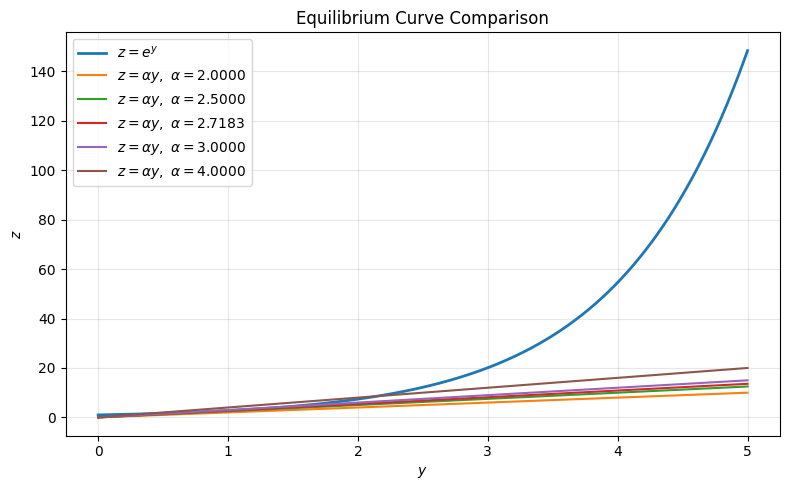

alpha = 2.500000000000 -> approximate equilibria: None in plotted range


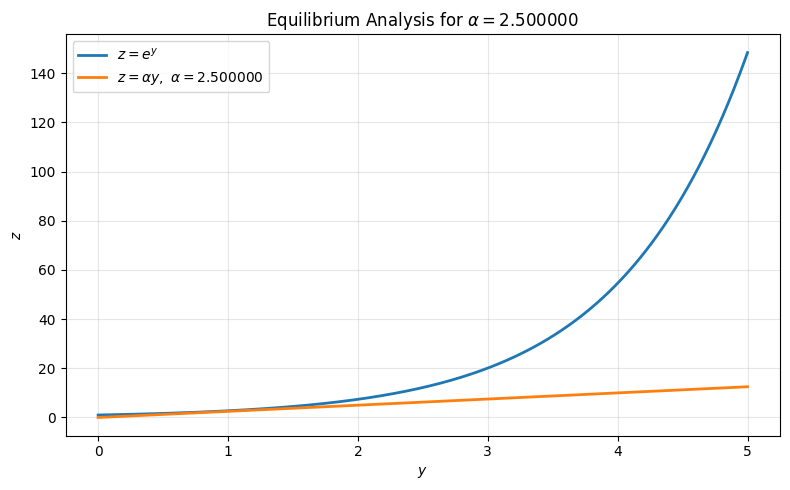

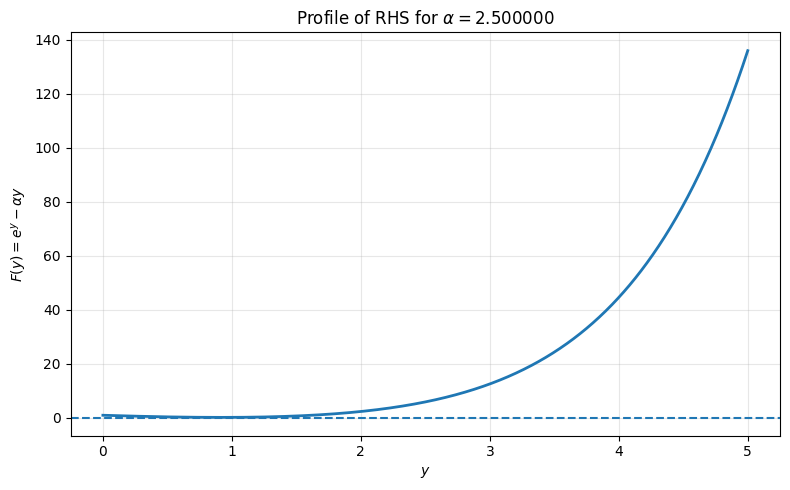

alpha = 2.718281828459 -> approximate equilibria: None in plotted range


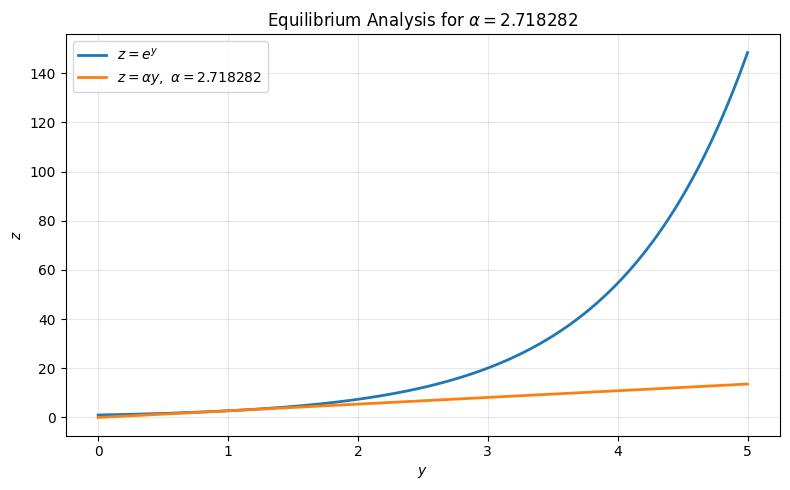

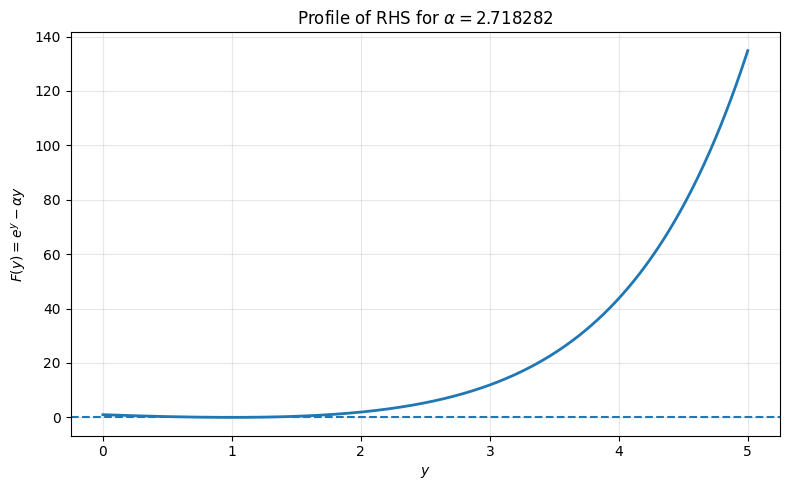

alpha = 3.200000000000 -> approximate equilibria: [0.5319556649895736, 1.6847941980318408]


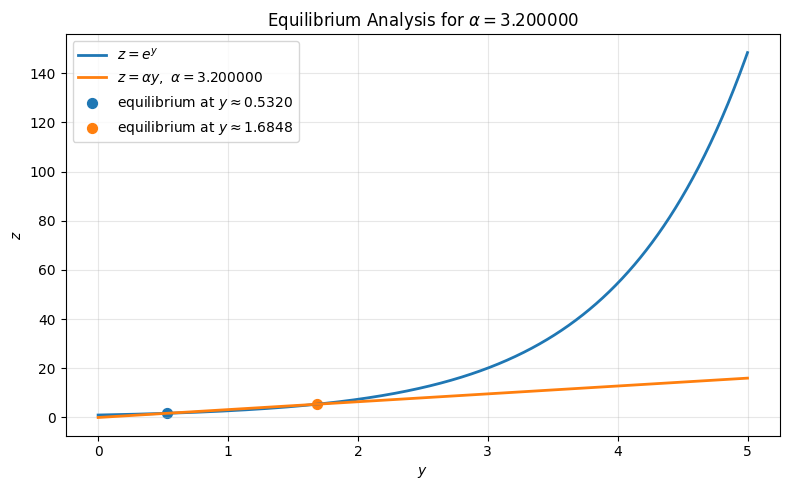

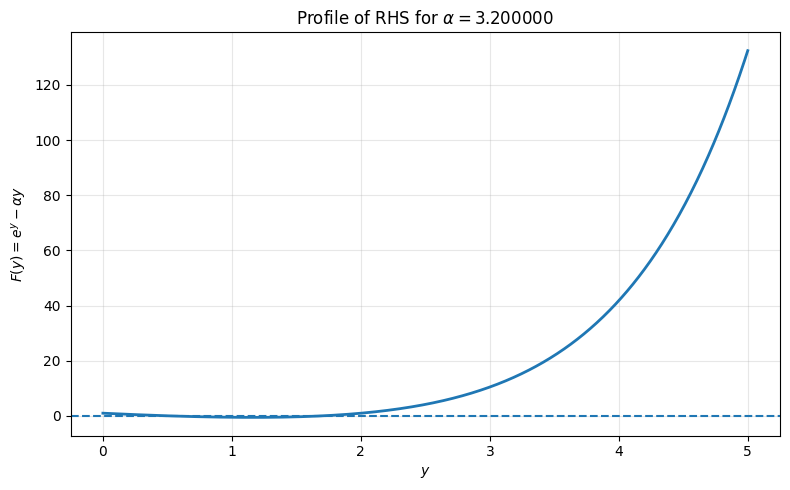

In [17]:
import main_analysis
main_analysis.run_analysis()

FIXED-STEP IMPROVED EULER RUNS


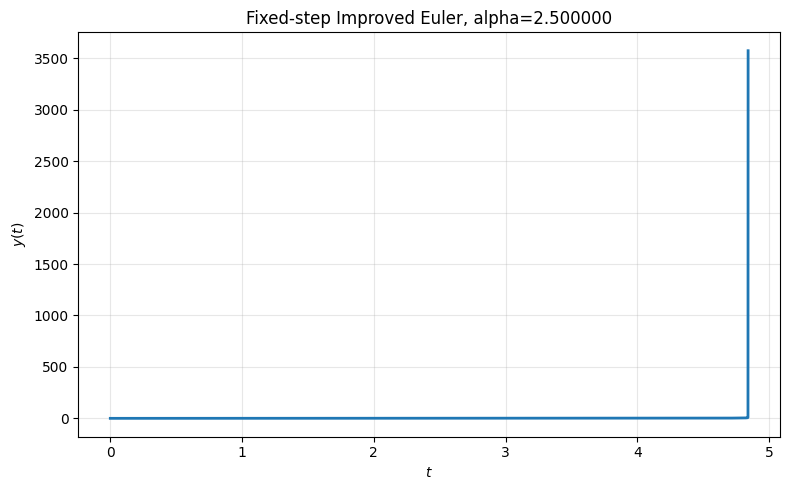

alpha=2.500000
  num_steps = 4841
  final_time = 4.841000
  final_value = 3573.712346
  blowup_detected = True
  termination_reason = Explosion threshold reached



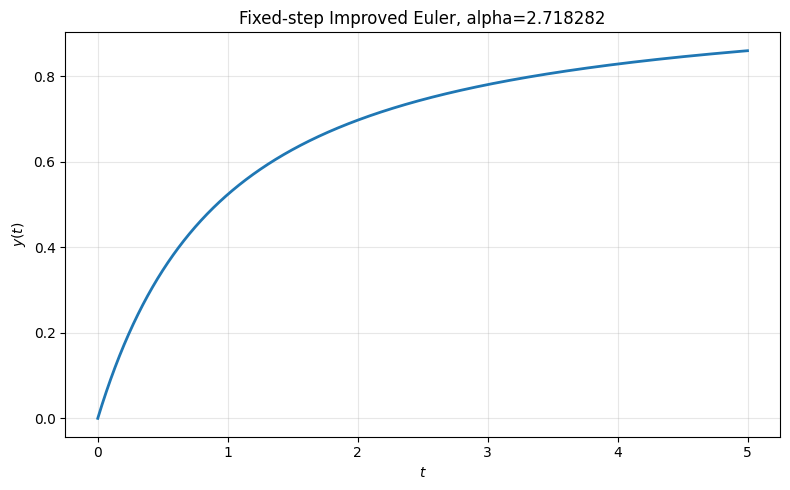

alpha=2.718282
  num_steps = 5000
  final_time = 5.000000
  final_value = 0.859522
  blowup_detected = False
  termination_reason = Reached tmax



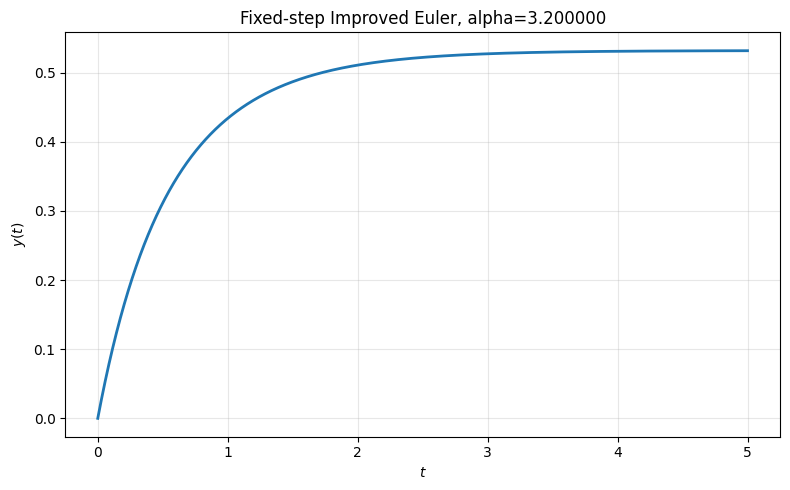

alpha=3.200000
  num_steps = 5000
  final_time = 5.000000
  final_value = 0.531723
  blowup_detected = False
  termination_reason = Reached tmax



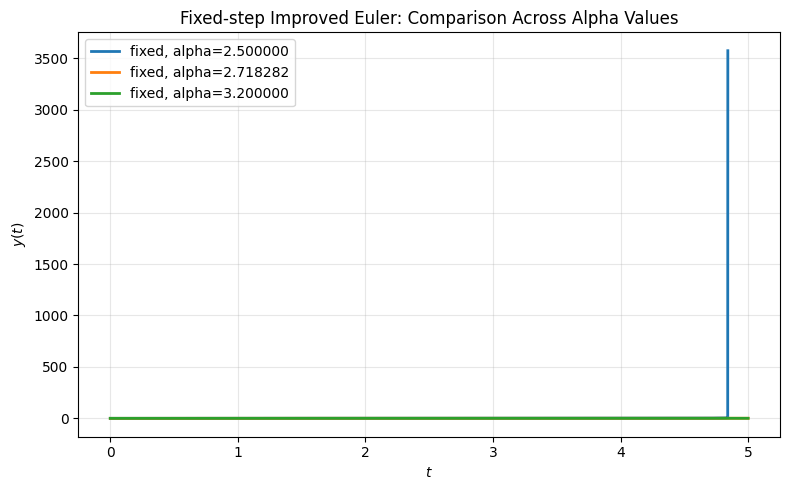

                 method     alpha  num_steps  final_time  final_value  \
0  improved_euler_fixed  2.500000       4841       4.841  3573.712346   
1  improved_euler_fixed  2.718282       5000       5.000     0.859522   
2  improved_euler_fixed  3.200000       5000       5.000     0.531723   

   blowup_detected           termination_reason  monotone_increasing  
0             True  Explosion threshold reached                 True  
1            False                 Reached tmax                 True  
2            False                 Reached tmax                 True  


In [18]:
import main_fixed
main_fixed.run_fixed()

ADAPTIVE IMPROVED EULER RUNS


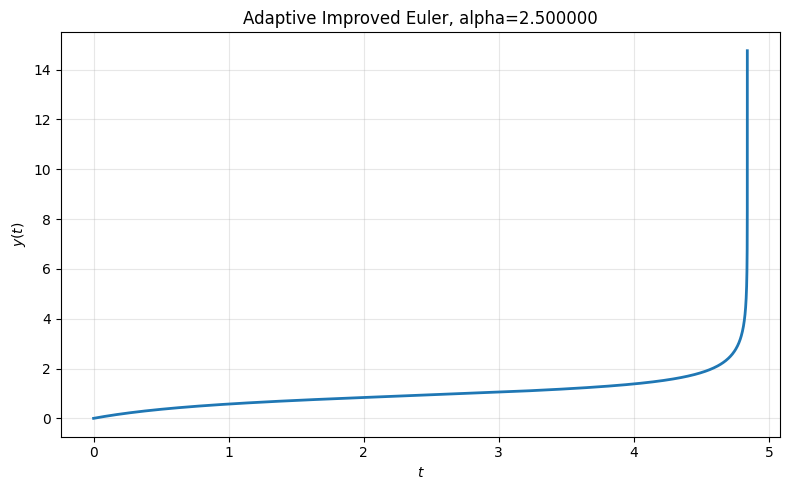

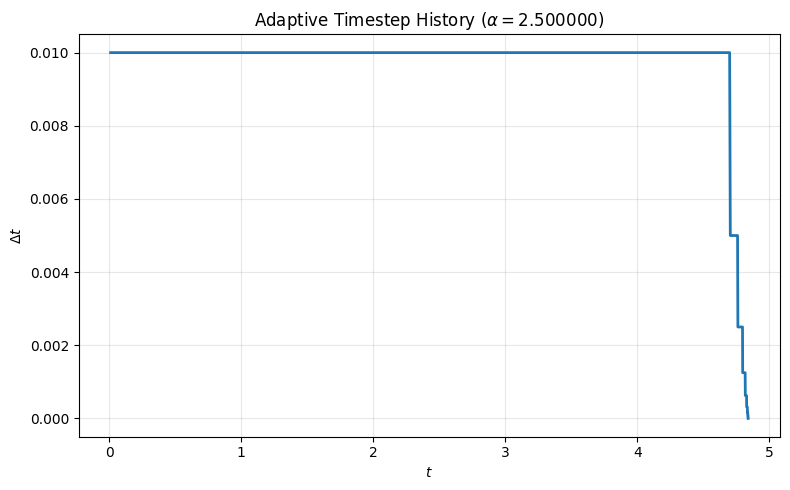

alpha=2.500000
  accepted_steps = 826
  rejected_steps = 20
  final_time = 4.840042
  final_value = 14.756393
  blowup_detected = True
  termination_reason = Step size fell below dt_min during rejection



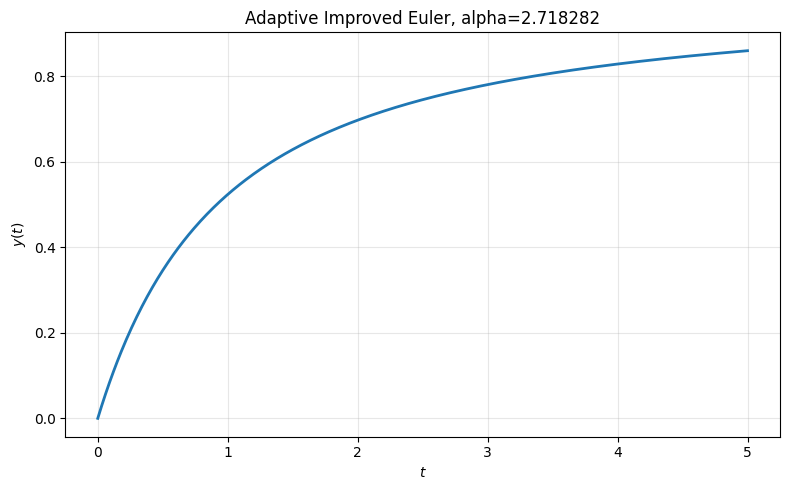

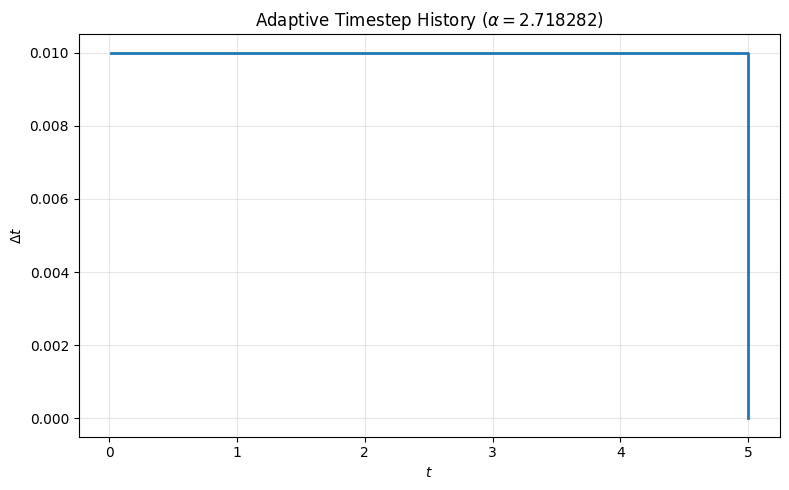

alpha=2.718282
  accepted_steps = 501
  rejected_steps = 0
  final_time = 5.000000
  final_value = 0.859521
  blowup_detected = False
  termination_reason = Reached tmax



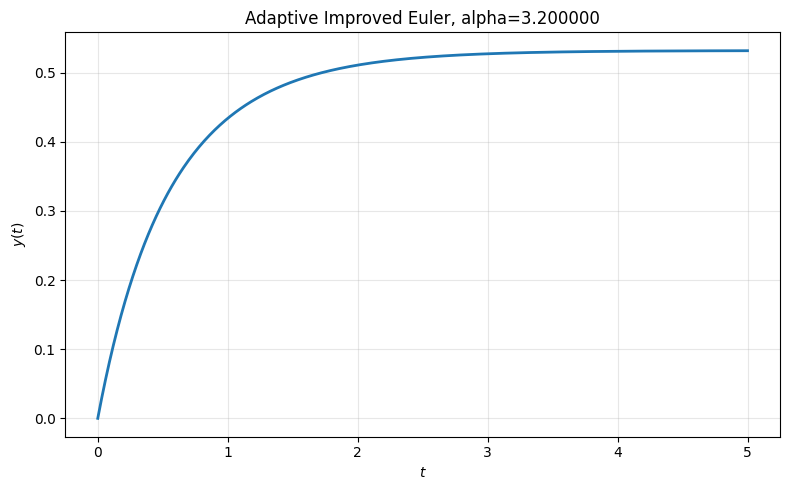

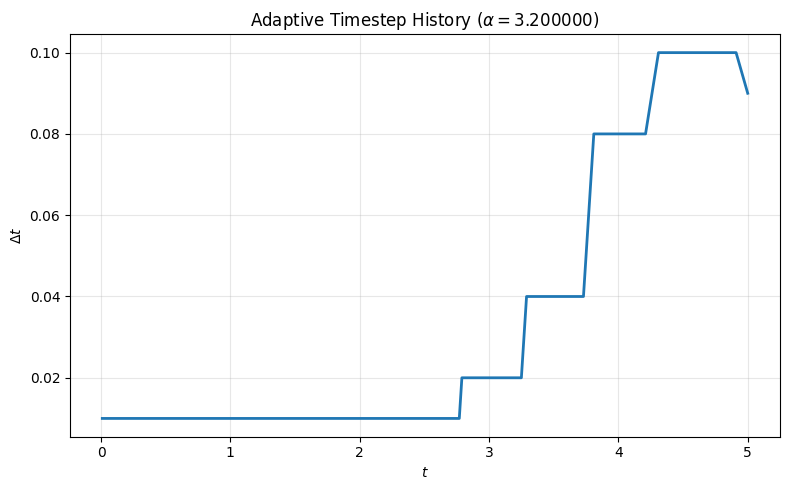

alpha=3.200000
  accepted_steps = 327
  rejected_steps = 0
  final_time = 5.000000
  final_value = 0.531721
  blowup_detected = False
  termination_reason = Reached tmax



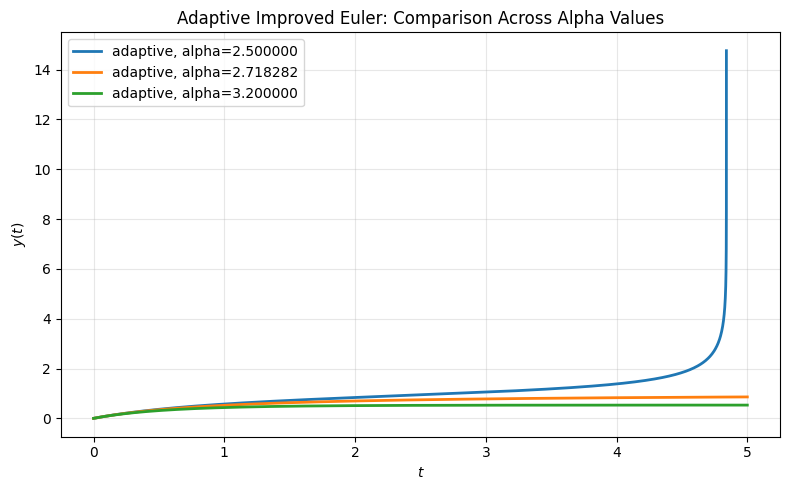

                    method     alpha  num_steps  final_time  final_value  \
0  improved_euler_adaptive  2.500000        826    4.840042    14.756393   
1  improved_euler_adaptive  2.718282        501    5.000000     0.859521   
2  improved_euler_adaptive  3.200000        327    5.000000     0.531721   

   blowup_detected                            termination_reason  \
0             True  Step size fell below dt_min during rejection   
1            False                                  Reached tmax   
2            False                                  Reached tmax   

   monotone_increasing  accepted_steps  rejected_steps        dt_min  dt_max  \
0                 True             826              20  1.907349e-08    0.01   
1                 True             501               0  6.217249e-14    0.01   
2                 True             327               0  1.000000e-02    0.10   

    dt_mean  
0  0.005860  
1  0.009980  
2  0.015291  


In [19]:
import main_adaptive
main_adaptive.run_adaptive()

In [20]:
fixed_df = pd.read_csv("outputs/fixed_summary.csv")
adaptive_df = pd.read_csv("outputs/adaptive_summary.csv")

print("Fixed-step summary")
display(fixed_df)

print("Adaptive summary")
display(adaptive_df)

Fixed-step summary


,method,alpha,num_steps,final_time,final_value,blowup_detected,termination_reason,monotone_increasing
0,improved_euler_fixed,2.500000,4841,4.841,3573.712346,True,Explosion threshold reached,True
1,improved_euler_fixed,2.718282,5000,5.000,0.859522,False,Reached tmax,True
2,improved_euler_fixed,3.200000,5000,5.000,0.531723,False,Reached tmax,True


Adaptive summary


,method,alpha,num_steps,final_time,final_value,blowup_detected,termination_reason,monotone_increasing,accepted_steps,rejected_steps,dt_min,dt_max,dt_mean
0,improved_euler_adaptive,2.500000,826,4.840042,14.756393,True,Step size fell below dt_min during rejection,True,826,20,1.907349e-08,0.01,0.005860
1,improved_euler_adaptive,2.718282,501,5.000000,0.859521,False,Reached tmax,True,501,0,6.217249e-14,0.01,0.009980
2,improved_euler_adaptive,3.200000,327,5.000000,0.531721,False,Reached tmax,True,327,0,1.000000e-02,0.10,0.015291


# Thermal Runaway ODE Project Report

## Project Title
Numerical Investigation of Thermal Runaway in a Nonlinear Ordinary Differential Equation Using Improved Euler Methods

---

## 1. Overview

This project studies the nonlinear ordinary differential equation

\[
\frac{dy}{dt} = e^y - \alpha y, \qquad y(0)=0, \qquad \alpha>0
\]

which models the competition between two physical effects in a combustible mixture:

- **heat generation**, represented by \( e^y \)
- **heat loss**, represented by \( -\alpha y \)

Here, \( y(t) \) is the nondimensional temperature rise above ambient temperature, and \( \alpha \) is a positive parameter measuring the strength of cooling.

The main goal of this project is to understand when the temperature remains bounded and when it blows up, and then to solve the equation numerically using:

1. equilibrium and graphical analysis,
2. the fixed-step improved Euler method,
3. a primitive adaptive timestep improved Euler method.

The project is implemented in Python and designed to run in Google Colab.

---

## 2. Mathematical Background

We consider the initial value problem

\[
\frac{dy}{dt} = e^y - \alpha y, \qquad y(0)=0.
\]

The behavior of the solution depends strongly on the parameter \( \alpha \).

### 2.1 Equilibrium Points

Equilibrium points \( y^* \) satisfy

\[
e^{y^*} = \alpha y^*.
\]

These correspond to the intersections of the curves

\[
z = e^y
\quad \text{and} \quad
z = \alpha y.
\]

If these curves intersect, the system may reach a steady temperature.  
If they do not intersect, the heat generation dominates and thermal runaway occurs.

---

## 3. Critical Parameter

The critical parameter occurs when the straight line \( z = \alpha y \) is tangent to the curve \( z = e^y \).

At tangency, both the function values and derivatives agree:

\[
e^{y^*} = \alpha y^*,
\qquad
e^{y^*} = \alpha.
\]

Combining these equations gives

\[
\alpha y^* = \alpha,
\]

so

\[
y^* = 1.
\]

Substituting into \( e^{y^*} = \alpha \) gives

\[
\alpha_{\mathrm{crit}} = e.
\]

Therefore,

\[
\boxed{\alpha_{\mathrm{crit}} = e \approx 2.718281828.}
\]

This is the threshold separating explosive and bounded behavior.

---

## 4. Interpretation of the Regimes

### Case 1: \( \alpha < e \)

The line \( z = \alpha y \) does not intersect the exponential curve.  
There is no equilibrium point.  
Heat generation dominates cooling, and the solution grows rapidly.

This corresponds to **thermal runaway** or **explosion**.

### Case 2: \( \alpha = e \)

The line is tangent to the exponential curve at \( y=1 \).  
There is exactly one equilibrium point.

The solution approaches the critical equilibrium slowly.

### Case 3: \( \alpha > e \)

The line intersects the exponential curve at two points.  
Starting from \( y(0)=0 \), the solution approaches the smaller attainable equilibrium.

This corresponds to **bounded heating** followed by stabilization.

---

## 5. Numerical Method

To solve the ODE numerically, we define

\[
F(y) = e^y - \alpha y.
\]

The improved Euler method is then written as a predictor-corrector method.

### Predictor Step

\[
\widetilde{y} = y_n + \Delta t\,F(y_n)
\]

### Corrector Step

\[
y_{n+1}
=
y_n
+
\frac{\Delta t}{2}
\left(
F(y_n) + F(\widetilde{y})
\right)
\]

This is a second-order explicit method and is more accurate than standard forward Euler.

---

## 6. Adaptive Timestep Strategy

For \( \alpha < e \), the solution can grow very quickly and may blow up in finite time.  
A fixed timestep may then become inefficient or inaccurate.

To handle this, an adaptive timestep method is used.

The code monitors the change

\[
\Delta y_n = |y_{n+1} - y_n|.
\]

The following logic is applied:

- if \( \Delta y_n \) is **too large**, reject the step and reduce \( \Delta t \),
- if \( \Delta y_n \) is **very small**, accept the step and increase \( \Delta t \),
- otherwise, accept the step with the current timestep.

This is a primitive adaptive method based on solution increments, which is exactly what the assignment requested.

---

## 7. Project Structure

The project may be written as either a modular multi-file codebase or a single classic Python module.

For the single-file version, the code contains:

- global configuration parameters,
- model definition,
- equilibrium analysis,
- fixed-step improved Euler solver,
- adaptive improved Euler solver,
- diagnostics,
- plotting,
- summary table generation,
- README generation,
- execution driver.

Typical output files are saved in the `outputs/` directory.

---

## 8. Main Components of the Code

### 8.1 Model Function

The model function evaluates

\[
F(y)=e^y-\alpha y.
\]

This is the right-hand side of the ODE and is used by all numerical solvers.

### 8.2 Equilibrium Analysis

The equilibrium module:

- computes the critical value \( \alpha_{\mathrm{crit}}=e \),
- estimates equilibrium points numerically,
- plots \( z=e^y \) and \( z=\alpha y \),
- helps interpret the physical regimes.

### 8.3 Fixed-Step Solver

This implements the improved Euler scheme using a constant timestep \( \Delta t \).

It is suitable for bounded cases and for general demonstration.

### 8.4 Adaptive Solver

This implements the same improved Euler scheme with timestep control based on \( |y_{n+1}-y_n| \).

It is especially useful in the explosive regime.

### 8.5 Diagnostics

The diagnostics section records:

- final time,
- final value,
- number of steps,
- accepted and rejected adaptive steps,
- monotonicity,
- blow-up detection,
- termination reason.

### 8.6 Plotting

The plotting section generates:

- equilibrium curve plots,
- right-hand-side profile plots,
- solution curves \( y(t) \),
- adaptive timestep history plots,
- comparison figures.

---

## 9. Numerical Parameters Used

Representative values of the parameter \( \alpha \) are chosen as:

- below critical: \( \alpha = 2.5 \),
- critical: \( \alpha = e \),
- above critical: \( \alpha = 3.2 \).

Typical numerical settings are:

- fixed timestep: \( \Delta t = 10^{-3} \),
- adaptive initial timestep: \( 10^{-2} \),
- minimum timestep: \( 10^{-8} \),
- maximum timestep: \( 10^{-1} \),
- explosion threshold: \( y = 20 \).

These values are reasonable for demonstrating the different solution behaviors.

---

## 10. Expected Results

### For \( \alpha = 2.5 < e \)

- no equilibrium point is attained,
- the solution increases rapidly,
- the solver eventually declares explosion when the threshold is reached.

### For \( \alpha = e \)

- the solution rises and approaches \( y=1 \),
- this is the critical case.

### For \( \alpha = 3.2 > e \)

- two equilibrium points exist,
- the solution starting from \( y(0)=0 \) approaches the smaller stable equilibrium.

---

## 11. Generated Outputs

The code produces figures such as:

- `equilibrium_curves_multi.png`
- `equilibrium_alpha_*.png`
- `rhs_profile_alpha_*.png`
- `fixed_solution_alpha_*.png`
- `adaptive_solution_alpha_*.png`
- `dt_history_alpha_*.png`
- `fixed_comparison.png`
- `adaptive_comparison.png`

It also produces summary tables such as:

- `fixed_summary.csv`
- `adaptive_summary.csv`

These outputs can be used directly in the project report.

---

## 12. Running the Project in Colab

If the project is stored in a single file called

`thermal_runaway_single_module.py`

then it can be run in either of two ways.

### Option 1: Run the whole script

```python
!python thermal_runaway_single_module.py